<a href="https://colab.research.google.com/github/kulasekara02/lstm_timeseries/blob/main/lstm_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

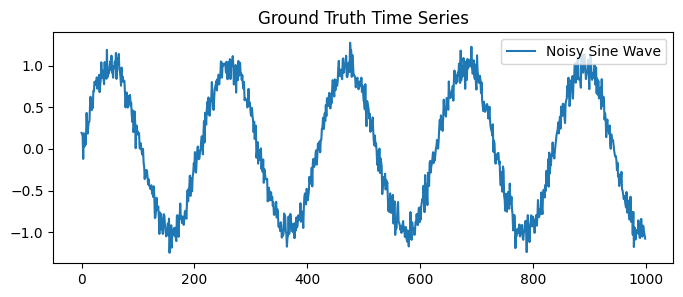

X shape: torch.Size([969, 30])
Y shape: torch.Size([969, 1])
Epoch 1/20, Train Loss: 0.5598, Val Loss: 0.4417
Epoch 2/20, Train Loss: 0.4361, Val Loss: 0.3178
Epoch 3/20, Train Loss: 0.2507, Val Loss: 0.1127
Epoch 4/20, Train Loss: 0.0758, Val Loss: 0.0591
Epoch 5/20, Train Loss: 0.0454, Val Loss: 0.0376
Epoch 6/20, Train Loss: 0.0322, Val Loss: 0.0287
Epoch 7/20, Train Loss: 0.0254, Val Loss: 0.0241
Epoch 8/20, Train Loss: 0.0213, Val Loss: 0.0211
Epoch 9/20, Train Loss: 0.0187, Val Loss: 0.0192
Epoch 10/20, Train Loss: 0.0171, Val Loss: 0.0174
Epoch 11/20, Train Loss: 0.0162, Val Loss: 0.0164
Epoch 12/20, Train Loss: 0.0150, Val Loss: 0.0155
Epoch 13/20, Train Loss: 0.0144, Val Loss: 0.0149
Epoch 14/20, Train Loss: 0.0142, Val Loss: 0.0147
Epoch 15/20, Train Loss: 0.0141, Val Loss: 0.0144
Epoch 16/20, Train Loss: 0.0135, Val Loss: 0.0143
Epoch 17/20, Train Loss: 0.0138, Val Loss: 0.0141
Epoch 18/20, Train Loss: 0.0138, Val Loss: 0.0141
Epoch 19/20, Train Loss: 0.0135, Val Loss: 0.014

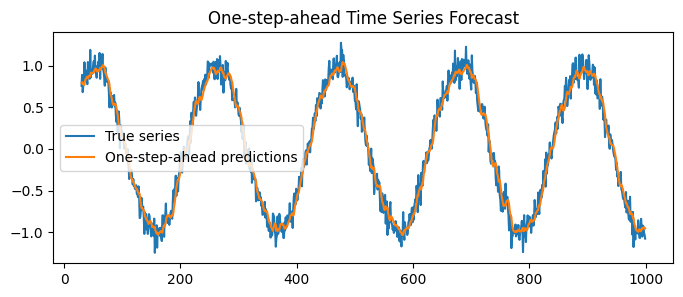

In [ ]:
#############################################
# 1) Install & Import Dependencies (if needed)
#############################################

# For basic PyTorch training and plotting
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

# Make sure plots appear inline in the Colab notebook
%matplotlib inline

#############################################
# 2) Generate a Synthetic Time Series
#############################################
torch.manual_seed(42)  # for reproducibility

T = 1000            # total time steps
time = torch.arange(0, T, dtype=torch.float32)

# Create a noisy sine wave
freq = 0.03
noise = 0.1 * torch.randn(T)  # Gaussian noise
series = torch.sin(freq * time) + noise

# Plot the raw data
plt.figure(figsize=(8, 3))
plt.plot(series, label="Noisy Sine Wave")
plt.title("Ground Truth Time Series")
plt.legend()
plt.show()

#############################################
# 3) Prepare the Dataset
#############################################
input_window = 30  # how many steps in the input sequence
horizon = 1        # predict 1 step ahead

Xs, ys = [], []
for i in range(T - input_window - horizon):
    Xs.append(series[i : i + input_window])
    ys.append(series[i + input_window : i + input_window + horizon])

X = torch.stack(Xs)  # shape: (N, input_window)
Y = torch.stack(ys)  # shape: (N, horizon)  # horizon=1 => shape (N, 1)

print("X shape:", X.shape)  # (num_samples, 30)
print("Y shape:", Y.shape)  # (num_samples, 1)

#############################################
# 4) Define LSTM Model
#############################################
class LSTMTimeSeries(nn.Module):
    def __init__(self, hidden_dim=16, num_layers=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        # For univariate time series, input_size=1
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        x shape: (batch_size, input_window)
        We'll transform x to (input_window, batch_size, 1) for the LSTM.
        """
        batch_size = x.size(0)

        # Reshape x => (seq_len=30, batch_size, input_dim=1)
        x = x.unsqueeze(-1).transpose(0, 1)

        # Initialize hidden states to zeros
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim)

        # Forward pass
        lstm_out, _ = self.lstm(x, (h0, c0))

        # We only need the final time step output: (batch_size, hidden_dim)
        last_out = lstm_out[-1, :, :]

        # Map to 1 dimension output
        out = self.fc(last_out).squeeze(-1)  # (batch_size,)
        return out

#############################################
# 5) Train/Validation Split & DataLoaders
#############################################
split_idx = int(0.8 * X.size(0))
X_train, X_val = X[:split_idx], X[split_idx:]
Y_train, Y_val = Y[:split_idx], Y[split_idx:]

train_ds = torch.utils.data.TensorDataset(X_train, Y_train)
val_ds   = torch.utils.data.TensorDataset(X_val, Y_val)

batch_size = 32
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl   = torch.utils.data.DataLoader(val_ds,   batch_size=batch_size)

#############################################
# 6) Instantiate Model, Loss, and Optimizer
#############################################
model = LSTMTimeSeries(hidden_dim=16, num_layers=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#############################################
# 7) Training Loop
#############################################
epochs = 20
for epoch in range(epochs):
    # ---- TRAIN ----
    model.train()
    train_loss_sum = 0.0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)              # (batch_size,)
        loss  = loss_fn(preds, yb.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * xb.size(0)
    train_loss = train_loss_sum / len(train_dl.dataset)

    # ---- VALIDATION ----
    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            preds = model(xb)
            loss  = loss_fn(preds, yb.squeeze(-1))
            val_loss_sum += loss.item() * xb.size(0)
    val_loss = val_loss_sum / len(val_dl.dataset)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

#############################################
# 8) One-Step-Ahead Prediction
#############################################
model.eval()
preds = []
# We'll produce a prediction for each time step, once it has "seen" the previous 30
for i in range(T - input_window):
    x_input = series[i : i + input_window].unsqueeze(0)  # shape (1, 30)
    with torch.no_grad():
        y_pred = model(x_input)
    preds.append(y_pred.item())

preds = torch.tensor(preds)

# Compare predictions with ground truth
plt.figure(figsize=(8, 3))
plt.plot(range(input_window, T), series[input_window:], label="True series")
plt.plot(range(input_window, T), preds, label="One-step-ahead predictions")
plt.title("One-step-ahead Time Series Forecast")
plt.legend()
plt.show()
